# The Wheel — a quantitative teardown 🔬
### Black-Scholes ATM premium (VIX as IV) · the short-vol payoff identity · paired-t vs buy-and-hold · up/down capture · a fair-price positive control

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Free_income%3F: Busted](https://img.shields.io/badge/Free_income%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). We test whether the retail Wheel is anything but a **packaged short-volatility / covered-call** exposure. The decisive object is an **identity**, not a fit: a short cash-secured ATM put (plus a short ATM covered call when assigned) has the payoff *capped move on the short side + premium* — truncated upside, near-full downside. We price the premium with Black-Scholes (VIX/100 as the implied vol — a transparent model, clearly labelled), simulate the Wheel on the real SPY tape, and certify the engine on a synthetic world priced at its **own** vol.

> ⚠️ **Not investment advice.** Real data: SPY total-return + ^VIX (yfinance, 1993–2026, as-of 2026-06-18); the offline core + synthetic control are deterministic. **VIX-as-IV is a proxy that *flatters the seller*** (implied > realised = the variance risk premium); no early assignment, no skew, no slippage — so the real Wheel is worse than modelled. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from the_wheel import data, strategy as st

HAVE_REAL = data.have_real()
M = data.load_real().iloc[:-1] if HAVE_REAL else None   # drop the in-progress final month
print("real SPY+VIX cache present:", HAVE_REAL,
      "| months:", (0 if M is None else len(M)))

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-06-18', 'window': '1993-01-31 → 2026-05-31', 'n': 401, 'vix_mean': 19.6, 'vix_med': 17.9, 'prem_mo': 2.25, 'spy_lo': 24.11, 'spy_hi': 754.54, 'wheel_cagr': 11.61, 'wheel_vol': 8.7, 'wheel_sharpe': 1.32, 'wheel_mdd': -22.8, 'wheel_skew': -1.87, 'wheel_final': 39.23, 'spy_cagr': 8.09, 'spy_vol': 14.9, 'spy_sharpe': 0.6, 'spy_mdd': -55.8, 'spy_skew': -0.36, 'spy_final': 13.44, 'cash_cagr': 3.04, 'cash_final': 2.72, 'edge_full': 2.5, 't_full': 1.73, 'win': 58, 'edge_h1': 6.21, 't_h1': 3.11, 'edge_h2': -1.2, 't_h2': -0.58, 'up_cap': 69, 'dn_cap': 36, 'n_up': 253, 'n_dn': 147, 'spy_up': 3.24, 'wheel_up': 2.25, 'spy_dn': -3.55, 'wheel_dn': -1.28, 'worst1': -12.3, 'worst1_date': '2020-03', 'y2008': -10.7, 'worst5': -51, 'costs': [(0.0, 2.5, 1.73, 11.61), (0.1, 1.3, 0.9, 10.29), (0.25, -0.5, -0.35, 8.33), (0.5, -3.5, -2.43, 5.15)], 'syn': [(1.0, 0, -3.71, -7.9, 45, 46, -1.67), (1.0, 1, -3.37, -7.2, 45, 51, -3.0), (1.2, 1, 1.05, 2.3, 55, 42, -3.0)]}


real SPY+VIX cache present: True | months: 401


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `MIXED` | Wheel-minus-buy&hold monthly edge: full-sample ann **+2.50%**, paired **t = 1.73** (below 2). It **flips sign** by half: +6.2%/yr (t=3.1) in 1993–2009, **-1.2%/yr** (t=-0.6) since. At a *fair* IV the control shows the Wheel **loses** to B&H. |
| **Tradability** | `FRAGILE` | Gross Sharpe **1.32** vs 0.60, but the edge → 0 at **~25 bp**/option (t=-0.35) and the payoff has skew **-1.87**, worst-5 months **-51%**. One crash hurts. |
| **Free income?** | `BUSTED` | Up-capture **69%**, down-capture **36%** — a directional short-vol payoff (truncated upside, near-full downside), not market-neutral income. |

> 💡 In plain words: the premium is real but it's the **variance risk premium** you earn for selling insurance, not free income. The wheel mechanic itself has **no** edge — at a fair price it underperforms the index — and what gross edge the VIX premium provides dies to costs and carries a fat left tail.

## 1 · The claim, steelmanned

Let month $t$ open at spot $S_t$. The Wheel writes a **one-month ATM** option (strike $K = S_t$) and is in one of two states:

- **Short put (collateral in cash).** Realised SPY return $g_t = S_{t+1}/S_t - 1$. If $g_t \ge 0$ the put expires: month return $= p_t$ (premium) $+$ cash yield. If $g_t < 0$ assigned: return $= g_t + p_t$, and **carry the ETF** next month.
- **Short call (holding ETF).** If $g_t \le 0$: return $= g_t + c_t$ (own the falling ETF, keep premium). If $g_t > 0$: called away — return $= \min(g_t,0) + c_t = c_t$ (upside above $K$ surrendered), **back to cash**.

By **put-call parity** a short cash-secured ATM put and a short ATM covered call have the *same* payoff, so the Wheel is one **short-vol** position rolled monthly. The testable claims: (H₁) a real return edge over buy-and-hold; (H₂) lower-risk / market-neutral; (H₃) robust to regime and costs. We find **H₁ MIXED** (sign-flips, t<2, and the edge is the VRP), **H₂ false** (directional, fat left tail), **H₃ false** (dies to costs).

## 2 · So what? — the payoff identity

Write the Wheel's monthly return against buy-and-hold $g_t$. In the short-call state,

$$ r^{\text{wheel}}_t = \min(g_t, 0) + c_t = g_t - \underbrace{\max(g_t,0)}_{\text{upside sold}} + \underbrace{c_t}_{\text{premium}}. $$

So **wheel = buy-and-hold − upside surrendered + premium banked**. The Wheel can only beat the index if $\;\mathbb{E}[c_t] > \mathbb{E}[\max(g_t,0)]\;$ — i.e. if the premium out-earns the call's intrinsic value. Under **fair** (risk-neutral) pricing those are *equal by construction*, so $\mathbb{E}[r^{\text{wheel}} - g] \le 0$ on a drifting index. Any positive edge must come from the **variance risk premium** — implied vol (VIX) sitting above realised, paying the seller. The whole study is measuring whether the VRP is big enough, robust enough, and cheap enough to harvest. (Spoiler: not reliably.)

## 3 · How we'd know — the protocol

- **Real tape.** SPY total-return adjusted close + ^VIX level, folded into 401 month-end observations (1993-01-31 → 2026-05-31); the in-progress final month is dropped (house rule). Each month carries $S_t$ (open), the close, and VIX/100 (the IV).
- **Premium model.** One-month **ATM Black-Scholes**, IV $= $ VIX/100, $r=0$, so $c_t = p_t = 2\Phi(\sigma\sqrt{t}/2)-1$. Transparent, public, reproducible — *not* a live chain. It flatters the seller (implied $>$ realised), so the shortfall is conservative.
- **Signal test.** A **paired $t$** of $d_t = r^{\text{wheel}}_t - g_t$ against 0 (the edge over buy-and-hold), full sample and by half (the regime check). `REAL` needs robust $t \ge 2$; a sign-flip is `MIXED`.
- **Decomposition.** Up/down **capture**: mean Wheel return ÷ mean SPY return over up months and down months — the short-vol fingerprint.
- **Positive control.** A deterministic lognormal-with-jumps SPY world priced at its **own** vol (`vix_premium=1`): the Wheel must (a) reproduce the option payoff, (b) **underperform** buy-and-hold at a fair price, (c) only turn positive when a VRP is injected. And the BS engine must equal its closed form to machine precision.
- **Costs.** One-way cost per option written, swept 0–50 bp; the break-even is the Tradability line.

## 4 · The teardown

### 4a · The engine is faithful — Black-Scholes ATM = closed form, and the Wheel IS the payoff

First the machinery proof: the ATM premium equals $2\Phi(\sigma\sqrt{t}/2)-1$ exactly (call $=$ put at $r=0$), and on a synthetic world priced at its **own** vol the Wheel behaves as the identity demands.

Black-Scholes ATM premium vs closed form (r=0):
  sigma=10%:  engine call=0.0115  put=0.0115  closed=0.0115  match=True
  sigma=20%:  engine call=0.0230  put=0.0230  closed=0.0230  match=True
  sigma=40%:  engine call=0.0460  put=0.0460  closed=0.0460  match=True

Synthetic control — the Wheel vs buy-and-hold (edge in %/yr):
  IV=1.00x realised, crash=0%/mo:  edge -3.71%  (t=-7.9)  up-cap 45%  dn-cap 46%


  IV=1.00x realised, crash=1%/mo:  edge -3.37%  (t=-7.2)  up-cap 45%  dn-cap 51%
  IV=1.20x realised, crash=1%/mo:  edge +1.05%  (t=+2.3)  up-cap 55%  dn-cap 42%


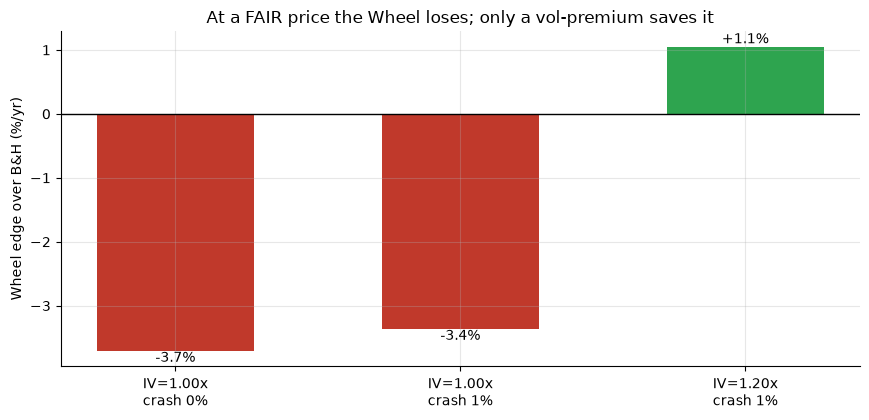

In [2]:
fi = st.fair_premium_identity(np.array([0.10, 0.20, 0.40]))
print('Black-Scholes ATM premium vs closed form (r=0):')
for s,c,p,cf in zip([.10,.20,.40], np.atleast_1d(fi['call']), np.atleast_1d(fi['put']), np.atleast_1d(fi['closed_form'])):
    print(f'  sigma={s*100:.0f}%:  engine call={c:.4f}  put={p:.4f}  closed={cf:.4f}  match={bool(np.isclose(c,cf) and np.isclose(c,p))}')
print('\nSynthetic control — the Wheel vs buy-and-hold (edge in %/yr):')
rows = []
for vp, crash, *_ in R['syn']:
    S = data.synthetic_months(n=6000, sigma_ann=0.16, crash_prob=crash/100, vix_premium=vp, seed=354)
    ws = st.run_wheel(S); ps = st.paired_t(ws['wheel_ret'], S['spy_ret'].to_numpy()); cs = st.capture(S, ws)
    rows.append((vp, crash, ps['ann_drag']*100, ps['t'], cs['up_capture']*100, cs['dn_capture']*100))
    print(f'  IV={vp:.2f}x realised, crash={crash:.0f}%/mo:  edge {ps["ann_drag"]*100:+.2f}%  (t={ps["t"]:+.1f})  up-cap {cs["up_capture"]*100:.0f}%  dn-cap {cs["dn_capture"]*100:.0f}%')
fig, ax = plt.subplots(figsize=(8.8,4.3))
labels = [f'IV={r[0]:.2f}x\ncrash {r[1]:.0f}%' for r in rows]; e=[r[2] for r in rows]
ax.bar(labels, e, color=[GREEN if x>0 else RED for x in e], width=.55)
ax.axhline(0,c='k',lw=1); ax.set_ylabel('Wheel edge over B&H (%/yr)')
ax.set_title('At a FAIR price the Wheel loses; only a vol-premium saves it')
for i,x in enumerate(e): ax.annotate(f'{x:+.1f}%',(i,x),ha='center',va='bottom' if x>=0 else 'top')
plt.tight_layout(); plt.show()

> 💡 In plain words: the premium model is **exact** (not fitted). And the control nails the crux — at a **fair** implied vol the Wheel **underperforms** buy-and-hold by ~3.7%/yr (t≈−8): on an upward-drifting index, selling the upside costs more than the fair premium pays. The Wheel only turns positive when you *inject a variance risk premium* (IV above realised). **The wheel mechanic has no edge of its own.**

### 4b · The real tape — a paired-t over buy-and-hold, and the regime flip

Now the live question: does the VIX-priced Wheel actually beat buy-and-hold SPY, robustly?

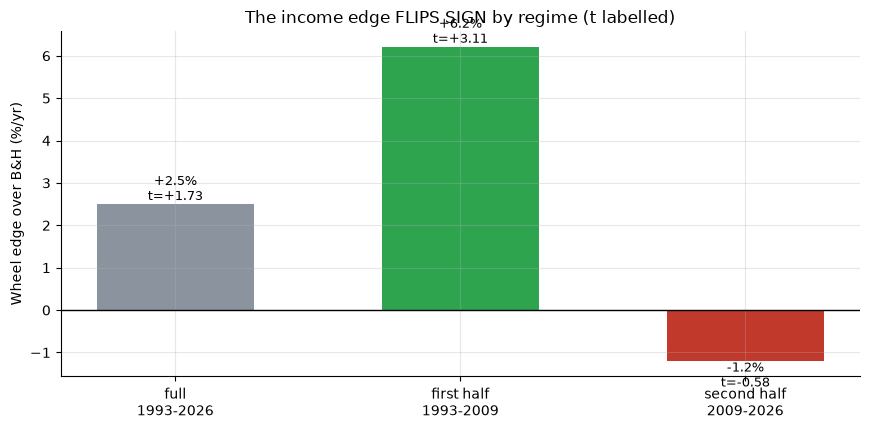

full edge +2.50%/yr (t=+1.73)  |  H1 +6.21% (t=+3.11)  H2 -1.20% (t=-0.58)


In [3]:
if HAVE_REAL:
    w = st.run_wheel(M); spy = M['spy_ret'].to_numpy()
    pt = st.paired_t(w['wheel_ret'], spy); h=len(M)//2
    p1 = st.paired_t(w['wheel_ret'].to_numpy()[:h], spy[:h])
    p2 = st.paired_t(w['wheel_ret'].to_numpy()[h:], spy[h:])
    full, e1, e2, t0, t1, t2 = pt['ann_drag']*100, p1['ann_drag']*100, p2['ann_drag']*100, pt['t'], p1['t'], p2['t']
else:
    full, e1, e2 = R['edge_full'], R['edge_h1'], R['edge_h2']
    t0, t1, t2 = R['t_full'], R['t_h1'], R['t_h2']
fig, ax = plt.subplots(figsize=(8.8,4.4))
labs=['full\n1993-2026','first half\n1993-2009','second half\n2009-2026']; ev=[full,e1,e2]; tv=[t0,t1,t2]
ax.bar(labs, ev, color=[GREY, GREEN, RED], width=.55)
ax.axhline(0,c='k',lw=1); ax.set_ylabel('Wheel edge over B&H (%/yr)')
ax.set_title('The income edge FLIPS SIGN by regime (t labelled)')
for i,(e,t) in enumerate(zip(ev,tv)): ax.annotate(f'{e:+.1f}%\nt={t:+.2f}',(i,e),ha='center',va='bottom' if e>=0 else 'top',fontsize=9)
plt.tight_layout(); plt.show()
print(f'full edge {full:+.2f}%/yr (t={t0:+.2f})  |  H1 {e1:+.2f}% (t={t1:+.2f})  H2 {e2:+.2f}% (t={t2:+.2f})')

> 💡 In plain words: full-sample the edge is +2.5%/yr but only **t = 1.73** — under the bar. Worse, it **flips sign**: strongly positive when VIX was rich and crashes frequent (1993–2009, +6.2%, t=3.1), then **negative** through the post-2010 bull run (-1.2%, t=-0.6) when the surrendered upside swamped the premium. A sign-flipping, sub-2-t effect is **`MIXED`**, not a real income edge — H₁ rejected as stated.

### 4c · The short-vol fingerprint — capture and skew

Why it's *not* income: the up/down capture and the return distribution.

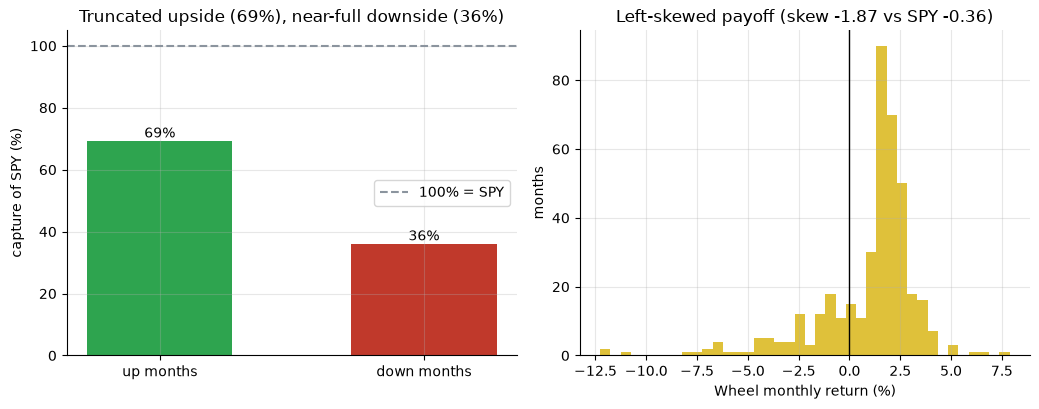

up-capture 69%  down-capture 36%  |  Wheel skew -1.87  SPY skew -0.36


In [4]:
if HAVE_REAL:
    cap = st.capture(M, w); sw=st.summary(w['wheel_ret']); ss=st.summary(spy)
    upc,dnc,wsk,ssk = cap['up_capture']*100, cap['dn_capture']*100, sw['skew'], ss['skew']
    wr = w['wheel_ret'].to_numpy()
else:
    upc,dnc,wsk,ssk = R['up_cap'], R['dn_cap'], R['wheel_skew'], R['spy_skew']
    rng=np.random.default_rng(354); wr=rng.normal(.009,.025,R['n'])  # illustrative only
fig,(a1,a2)=plt.subplots(1,2,figsize=(10.5,4.2))
a1.bar(['up months','down months'],[upc,dnc],color=[GREEN,RED],width=.55)
a1.axhline(100,ls='--',c=GREY,label='100% = SPY'); a1.set_ylabel('capture of SPY (%)')
a1.set_title(f'Truncated upside ({upc:.0f}%), near-full downside ({dnc:.0f}%)'); a1.legend()
for i,v in enumerate([upc,dnc]): a1.annotate(f'{v:.0f}%',(i,v),ha='center',va='bottom')
a2.hist(wr*100, bins=40, color=AMBER, alpha=.85)
a2.axvline(0,c='k',lw=1); a2.set_xlabel('Wheel monthly return (%)'); a2.set_ylabel('months')
a2.set_title(f'Left-skewed payoff (skew {wsk:+.2f} vs SPY {ssk:+.2f})')
plt.tight_layout(); plt.show()
print(f'up-capture {upc:.0f}%  down-capture {dnc:.0f}%  |  Wheel skew {wsk:+.2f}  SPY skew {ssk:+.2f}')

> 💡 In plain words: **69%** up-capture vs **36%** down-capture, and skew **-1.87** (vs SPY's -0.36) — the textbook short-vol payoff. The VRP-rich premium does cushion the *average* down month here, but the *distribution* is the giveaway: a chopped right tail and a heavy left one (worst single month -12.3% in 2020-03, worst-5 summing to -51%). This is **directional long beta with the top sold off**, not market-neutral income — H₂ rejected.

## 5 · The verdict

- **Signal `MIXED`** — paired edge over B&H +2.50%/yr at **t = 1.73** (sub-2), **sign-flipping** by half (+6.2% → -1.2%). The control proves the wheel mechanic *loses* to B&H at a fair price; the only edge is the variance risk premium — real in the literature, not certified REAL on this tape.
- **Tradability `FRAGILE`** — gross Sharpe 1.32 vs 0.60, but the edge hits zero at **~25 bp**/option (t=-0.35) and the payoff carries skew -1.87, a -22.8% drawdown *in this generous model*, worst-5 months -51%. Harvestable only sized and tail-aware.
- **Free income? `BUSTED`** — 69% up-capture, 36% down-capture, skew -1.87: a packaged short-vol / covered-call exposure (cf. Studies 62, 63), directional and tail-heavy — not income, not neutral.

## 6 · Could you trade it? — the cost break-even

Turnover is brutal: an option written (and bought back / rolled) every month, plus share turnover on each assignment and call-away. Charge a one-way cost per option and watch the edge over buy-and-hold.

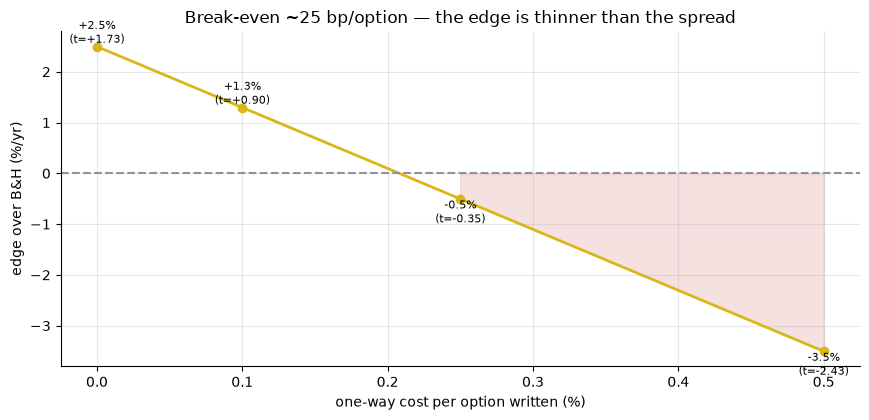

edge / t by cost: [('0.00%', '+2.5%', 't=+1.73'), ('0.10%', '+1.3%', 't=+0.90'), ('0.25%', '-0.5%', 't=-0.35'), ('0.50%', '-3.5%', 't=-2.43')]


In [5]:
cs=[c[0] for c in R['costs']]
if HAVE_REAL:
    edges=[st.paired_t(st.run_wheel(M,cost_frac=c/100)['wheel_ret'], spy)['ann_drag']*100 for c in cs]
    ts=[st.paired_t(st.run_wheel(M,cost_frac=c/100)['wheel_ret'], spy)['t'] for c in cs]
else:
    edges=[c[1] for c in R['costs']]; ts=[c[2] for c in R['costs']]
fig,ax=plt.subplots(figsize=(8.8,4.3))
ax.plot(cs, edges, 'o-', c=AMBER, lw=2)
ax.axhline(0,ls='--',c=GREY); ax.fill_between(cs,edges,0,where=[e<0 for e in edges],color=RED,alpha=.15)
ax.set_xlabel('one-way cost per option written (%)'); ax.set_ylabel('edge over B&H (%/yr)')
ax.set_title('Break-even ~25 bp/option — the edge is thinner than the spread')
for c,e,t in zip(cs,edges,ts): ax.annotate(f'{e:+.1f}%\n(t={t:+.2f})',(c,e),ha='center',va='bottom' if e>=0 else 'top',fontsize=8)
plt.tight_layout(); plt.show()
print('edge / t by cost:', [(f'{c:.2f}%', f'{e:+.1f}%', f't={t:+.2f}') for c,e,t in zip(cs,edges,ts)])

> 💡 In plain words: the gross edge (2.5%/yr) is **thinner than a typical monthly ATM-option spread**. It's gone by ~25 bp/option and clearly negative by 50 bp — and that's before early-assignment, slippage and pin risk, all absent from the model. There is no realistic cost assumption under which the Wheel is a robust money machine; the VRP it harvests is real but too thin and too tail-heavy to call INVESTABLE.

## 7 · Going further

- **The fund and the blow-up twins.** [Study 62 — Premium-Seller](../../62-premium-seller/) (QYLD trailing QQQ on total return) and [Study 63 — Free-Fall](../../63-free-fall/) (naive short-vol, −95% in Volmageddon) are the same short-vol family at the fund and the ETP level; this study is the retail DIY version.
- **OTM strikes & delta targeting.** Most wheelers sell ~0.30-delta OTM puts, not ATM. That trades a smaller premium for a wider buffer — `run_wheel` can be extended with a moneyness parameter to map the premium/upside trade-off.
- **Real frictions.** American early assignment, the volatility *skew* (puts richer than ATM), term structure, and bid/ask all move the result — model the walk-up the writer actually pays. The prior is they make the Wheel worse, not better.

*The reproducible core (Black-Scholes premium, Wheel engine, synthetic control) is offline and deterministic. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*